<a href="https://colab.research.google.com/github/Alchwalch/Deep-Learning-Study/blob/main/Image%20Detection/AlexNet_numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cited from:
https://github.com/oreilly-japan/deep-learning-from-scratch/blob/master/common

In [1]:
!pip install cupy-cuda12x
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [2]:
import cupy as cp
import numpy as np
cp.cuda.set_allocator(cp.cuda.MemoryPool().malloc)
from collections import OrderedDict

im2col 결과만 알자...

In [3]:
def im2col(input_data, filter_h,filter_w, stride=1, pad=0):
    N, C, H, W = input_data.shape
    out_h=(H+2*pad-filter_h)//stride+1
    out_w=(W+2*pad-filter_w)//stride+1

    img=cp.pad(input_data, [(0,0),(0,0),(pad,pad),(pad,pad)], 'constant')
    col=cp.zeros((N,C,filter_h,filter_w,out_h,out_w))

    for y in range(filter_h):
      y_max=y+stride*out_h
      for x in range(filter_w):
        x_max=x+stride*out_w
        col[:, :, y, x, :, :] = img[:, :, y:y_max:stride, x:x_max:stride]

    col=col.transpose(0,4,5,1,2,3).reshape(N*out_h*out_w,-1)
    return col

In [4]:
def col2im(col, input_shape, filter_h, filter_w, stride=1, pad=0):
    N, C, H, W = input_shape
    out_h = (H + 2*pad - filter_h)//stride + 1
    out_w = (W + 2*pad - filter_w)//stride + 1
    col = col.reshape(N, out_h, out_w, C, filter_h, filter_w).transpose(0, 3, 4, 5, 1, 2)

    img = cp.zeros((N, C, H + 2*pad + stride - 1, W + 2*pad + stride - 1))
    for y in range(filter_h):
      y_max=y+stride*out_h
      for x in range(filter_w):
        x_max=x+stride*out_w
        img[:, :, y:y_max:stride, x:x_max:stride] += col[:, :, y, x, :, :]

    return img[:, :, pad:H + pad, pad:W + pad]

In [5]:
class Convolution:
  def __init__(self,W,b,stride=1,pad=0):
    self.W=W
    self.b=b
    self.stride=stride
    self.pad=pad

    self.x = None
    self.col = None
    self.col_W = None

    self.dW = None
    self.db = None

  def forward(self,x):
    FN,C,FH,FW=self.W.shape
    N,C,H,W=x.shape
    out_h=1+int((H+2*self.pad-FH)/self.stride)
    out_w=1+int((W+2*self.pad-FW)/self.stride)

    col=im2col(x,FH,FW,self.stride,self.pad)
    col_W=self.W.reshape(FN,-1).T

    out=col@col_W+self.b
    out=out.reshape(N,out_h,out_w,-1).transpose(0,3,1,2)

    self.x = x
    self.col = col
    self.col_W = col_W

    return out

  def backward(self,dout):
    FN,C,FH,FW=self.W.shape
    dout=dout.transpose(0,2,3,1).reshape(-1,FN)
    #(N*H*W,(C=FN))

    self.db=cp.sum(dout,axis=0) #(1,C)
    self.dW=self.col.T @ dout
    self.dW=self.dW.transpose(1,0).reshape(FN,C,FH,FW)

    #print(str(dout.shape)+"  "+str(self.W.shape))
    dcol=dout@self.col_W.T
    dx=col2im(dcol,self.x.shape,FH,FW,self.stride,self.pad)

    return dx

In [6]:
class MaxPooling:
  def __init__(self,pool_h,pool_w,stride=2,pad=0):
    self.pool_h=pool_h
    self.pool_w=pool_w
    self.stride=stride
    self.pad=pad

    self.x=None
    self.arg_max=None

  def forward(self,x):
    N,C,H,W=x.shape
    out_h = int(1 + (H - self.pool_h) / self.stride)
    out_w = int(1 + (W - self.pool_w) / self.stride)

    col = im2col(x, self.pool_h, self.pool_w, self.stride, self.pad)
    col = col.reshape(-1, self.pool_h*self.pool_w)

    arg_max = cp.argmax(col, axis=1)
    out = cp.max(col, axis=1)
    out=out.reshape(N,out_h,out_w,C).transpose(0,3,1,2)

    self.x=x
    self.arg_max=arg_max

    return out

  def backward(self,dout):
    dout=dout.transpose(0,2,3,1)

    pool_size=self.pool_h*self.pool_w
    dmax=cp.zeros((dout.size,pool_size)) #(N*oh*ow*C, pool_size)
    dmax[cp.arange(self.arg_max.size), self.arg_max.flatten()] = dout.flatten()
    dmax = dmax.reshape(dout.shape + (pool_size,)) #(N,oh,ow,c,pool_size)

    dcol = dmax.reshape(dmax.shape[0] * dmax.shape[1] * dmax.shape[2], -1)
    dx = col2im(dcol, self.x.shape, self.pool_h, self.pool_w, self.stride, self.pad)

    return dx

LRN reference: https://github.com/chainer/chainer/blob/master/chainer/functions/normalization/local_response_normalization.py

In [7]:
class LocalResponseNormalization:
  def __init__(self,k=2.0,n=5,alpha=1e-4,beta=0.75):
    self.k=k
    self.n=n
    self.alpha=alpha
    self.beta=beta

    self.x=None
    self.scale=None

  def forward(self,x):
    N,C,H,W=x.shape
    self.x=x
    self.scale=cp.zeros_like(x)

    for i in range(C):
        ch_start = max(0, i - self.n // 2)
        ch_end = min(C, i + self.n // 2 + 1)
        self.scale[:, i, :, :] = self.k + self.alpha * cp.sum(
            x[:, ch_start:ch_end, :, :] ** 2, axis=1
        )

    out = x / (self.scale ** self.beta)
    return out

  def backward(self, dout):
    x = self.x
    N, C, H, W = x.shape
    dx = cp.zeros_like(x)

    for i in range(C):
        ch_start = max(0, i - self.n // 2)
        ch_end = min(C, i + self.n // 2 + 1)
        for j in range(ch_start, ch_end):
            dx[:, j, :, :] += dout[:, i, :, :] * \
                (-self.beta * (self.scale[:, i, :, :] ** (-self.beta - 1))) * \
                (2 * self.alpha * x[:, j, :, :])

    dx += dout * (self.scale ** (-self.beta))
    return dx


In [8]:
class ReLU:
  def __init__(self):
      self.mask = None

  def forward(self, x):
      self.mask = (x <= 0)
      out = x.copy()
      out[self.mask] = 0

      return out

  def backward(self, dout):
      dout[self.mask] = 0
      dx = dout

      return dx

In [9]:
class Affine:
  def __init__(self, W, b):
      self.W =W
      self.b = b

      self.x = None
      self.original_x_shape = None

      self.dW = None
      self.db = None

  def forward(self, x):

      self.original_x_shape = x.shape
      x = x.reshape(x.shape[0], -1)
      self.x = x

      out = cp.dot(self.x, self.W) + self.b

      return out

  def backward(self, dout):
      dx = cp.dot(dout, self.W.T)
      self.dW = cp.dot(self.x.T, dout)
      self.db = cp.sum(dout, axis=0)

      dx = dx.reshape(*self.original_x_shape)
      return dx

In [10]:
class Dropout:
  def __init__(self,dropout_ratio=0.5):
    self.dropout_ratio=dropout_ratio
    self.mask=None

  def forward(self,x,train=True):
    if train:
      self.mask=cp.random.rand(*x.shape)>self.dropout_ratio
      return x*self.mask
    else:
      return x*(1.0-self.dropout_ratio)

  def backward(self,dout):
    return dout*self.mask

In [11]:
def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - cp.max(x, axis=0)
        y = cp.exp(x) / cp.sum(cp.exp(x), axis=0)
        return y.T

    x = x - cp.max(x)
    return cp.exp(x) / cp.sum(cp.exp(x))

In [12]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)


    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -cp.sum(cp.log(y[cp.arange(batch_size), t] + 1e-7)) / batch_size


In [13]:
class SoftmaxWithLoss:
  def __init__(self):
    self.loss=None
    self.y=None
    self.t=None

  def forward(self,x,t):
    self.t=t
    self.y=softmax(x)
    self.loss=cross_entropy_error(self.y,self.t)
    return self.loss

  def backward(self,dout=1):
    batch_size=self.t.shape[0]
    dx=(self.y-self.t)/batch_size
    return dx

논문에 나온 옵티마이저로 하긴 귀찮아서 그냥 Adam 가져옴

In [14]:
class Adam:
  def __init__(self,lr=0.001,beta1=0.9,beta2=0.999):
    self.lr=lr
    self.beta1=beta1
    self.beta2=beta2
    self.t=0
    self.m=None
    self.v=None


  def update(self,params,grads):
    if self.m is None:
      self.m={}
      self.v={}
      for key,val in params.items():
        self.m[key]=cp.zeros_like(val)
        self.v[key]=cp.zeros_like(val)

    self.t+=1
    for key in params.keys():
      #print(key)
      grad=grads[key]
      self.m[key]=self.beta1*self.m[key]+(1-self.beta1)*grad
      self.v[key]=self.beta2*self.v[key]+(1-self.beta2)*grad**2
      m_hat=self.m[key]/(1-self.beta1**self.t)
      v_hat=self.v[key]/(1-self.beta2**self.t)
      params[key]-=self.lr*m_hat/(cp.sqrt(v_hat)+1e-8)

Reference: [simple_convnet](https://github.com/oreilly-japan/deep-learning-from-scratch/blob/master/ch07/simple_convnet.py), [블로그](https://daeun-computer-uneasy.tistory.com/35)

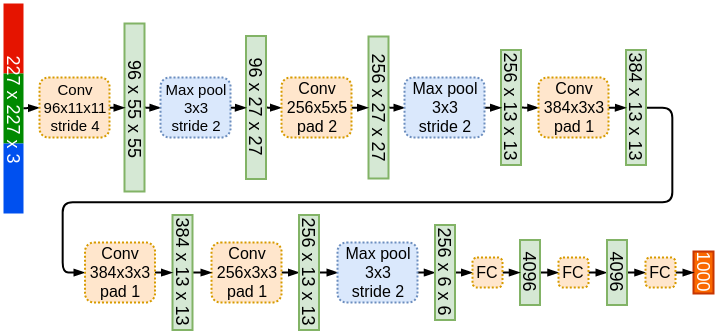

In [15]:
class AlexNet:
  def __init__(self,input_dim=(3,227,227),
               conv_param =
                {'filter_num':[96,128,384,192,128],'filter_size':[11,5,3,3,3],
                 'pad':[0,2,1,1,1],'stride':[4,1,1,1,1]},
               hidden_size=4096, output_size=1000, weight_init_std=0.01):
    filter_num=conv_param['filter_num']
    self.filter_num=filter_num
    filter_size=conv_param['filter_size']
    pad=conv_param['pad']
    stride=conv_param['stride']
    input_size=input_dim[1]
    conv1_out = (input_size - filter_size[0] + 2*pad[0]) / stride[0] + 1  # 55
    pool1_out = (conv1_out - 3) / 2 + 1 #27
    conv2_out = (pool1_out - filter_size[1] + 2*pad[1]) / stride[1] + 1  # 27
    pool2_out = (conv2_out - 3) / 2 + 1  # 13
    conv3_out = (pool2_out - filter_size[2] + 2*pad[2]) / stride[2] + 1  # 13
    conv4_out = (conv3_out - filter_size[3] + 2*pad[3]) / stride[3] + 1  # 13
    conv5_out = (conv4_out - filter_size[4] + 2*pad[4]) / stride[4] + 1  # 13
    pool3_out = int((conv5_out - 3) / 2 + 1)  # 6
    self.pool3_out=pool3_out
    pool_output_size = filter_num[4] * 2 * pool3_out * pool3_out  # 128*2 * 6 * 6 = 9216
    self.params={}
    # Conv1 (전체)
    self.params['W1'] = weight_init_std * cp.random.randn(filter_num[0], input_dim[0], filter_size[0], filter_size[0])
    self.params['b1'] = cp.zeros(filter_num[0])

    # Conv2 (2분할, 각각 48채널 입력)
    self.params['W2_1'] = weight_init_std * cp.random.randn(filter_num[1], filter_num[0]//2, filter_size[1], filter_size[1])
    self.params['W2_2'] = weight_init_std * cp.random.randn(filter_num[1], filter_num[0]//2, filter_size[1], filter_size[1])
    self.params['b2_1'] = cp.zeros(filter_num[1])
    self.params['b2_2'] = cp.zeros(filter_num[1])

    # Conv3 (합침, 256채널 입력)
    self.params['W3'] = weight_init_std * cp.random.randn(filter_num[2], filter_num[1]*2, filter_size[2], filter_size[2])
    self.params['b3'] = cp.zeros(filter_num[2])

    # Conv4 (다시 2분할, 192채널 입력)
    self.params['W4_1'] = weight_init_std * cp.random.randn(filter_num[3], filter_num[2]//2, filter_size[3], filter_size[3])
    self.params['W4_2'] = weight_init_std * cp.random.randn(filter_num[3], filter_num[2]//2, filter_size[3], filter_size[3])
    self.params['b4_1'] = cp.zeros(filter_num[3])
    self.params['b4_2'] = cp.zeros(filter_num[3])

    # Conv5 (분할 유지, 192채널 입력)
    self.params['W5_1'] = weight_init_std * cp.random.randn(filter_num[4], filter_num[3], filter_size[4], filter_size[4])
    self.params['W5_2'] = weight_init_std * cp.random.randn(filter_num[4], filter_num[3], filter_size[4], filter_size[4])
    self.params['b5_1'] = cp.zeros(filter_num[4])
    self.params['b5_2'] = cp.zeros(filter_num[4])

    # Pool3 후 FC (합침)

    # FC1
    self.params['W6'] = weight_init_std * cp.random.randn(pool_output_size, hidden_size)
    self.params['b6'] = cp.zeros(hidden_size)
    # FC2
    self.params['W7'] = weight_init_std * cp.random.randn(hidden_size, hidden_size)
    self.params['b7'] = cp.zeros(hidden_size)
    # FC3
    self.params['W8'] = weight_init_std * cp.random.randn(hidden_size, output_size)
    self.params['b8'] = cp.zeros(output_size)

    self.seq1=OrderedDict()
    self.seq1['Conv']=Convolution(self.params['W1'],self.params['b1'],stride[0],pad[0])
    self.seq1['ReLU']=ReLU()
    self.seq1['LRN']=LocalResponseNormalization()
    self.seq1['Pool']=MaxPooling(pool_h=3,pool_w=3,stride=2)

    self.seq2_1=OrderedDict()
    self.seq2_1['Conv']=Convolution(self.params['W2_1'],self.params['b2_1'],stride[1],pad[1])
    self.seq2_1['ReLU']=ReLU()
    self.seq2_1['LRN']=LocalResponseNormalization()
    self.seq2_1['Pool']=MaxPooling(pool_h=3,pool_w=3,stride=2)

    self.seq2_2=OrderedDict()
    self.seq2_2['Conv']=Convolution(self.params['W2_2'],self.params['b2_2'],stride[1],pad[1])
    self.seq2_2['ReLU']=ReLU()
    self.seq2_2['LRN']=LocalResponseNormalization()
    self.seq2_2['Pool']=MaxPooling(pool_h=3,pool_w=3,stride=2)

    self.seq3=OrderedDict()
    self.seq3['Conv']=Convolution(self.params['W3'],self.params['b3'],stride[2],pad[2])
    self.seq3['ReLU']=ReLU()

    self.seq4_1=OrderedDict()
    self.seq4_1['Conv1']=Convolution(self.params['W4_1'],self.params['b4_1'],stride[3],pad[3])
    self.seq4_1['ReLU1']=ReLU()
    self.seq4_1['Conv2']=Convolution(self.params['W5_1'],self.params['b5_1'],stride[4],pad[4])
    self.seq4_1['ReLU2']=ReLU()
    self.seq4_1['Pool']=MaxPooling(pool_h=3,pool_w=3,stride=2)

    self.seq4_2=OrderedDict()
    self.seq4_2['Conv1']=Convolution(self.params['W4_2'],self.params['b4_2'],stride[3],pad[3])
    self.seq4_2['ReLU1']=ReLU()
    self.seq4_2['Conv2']=Convolution(self.params['W5_2'],self.params['b5_2'],stride[4],pad[4])
    self.seq4_2['ReLU2']=ReLU()
    self.seq4_2['Pool']=MaxPooling(pool_h=3,pool_w=3,stride=2)

    self.seq5=OrderedDict()
    self.seq5['DropOut1']=Dropout(0.5)
    self.seq5['Affine1']=Affine(self.params['W6'],self.params['b6'])
    self.seq5['ReLU1']=ReLU()
    self.seq5['DropOut2']=Dropout(0.5)
    self.seq5['Affine2']=Affine(self.params['W7'],self.params['b7'])
    self.seq5['ReLU2']=ReLU()
    self.seq5['Affine3']=Affine(self.params['W8'],self.params['b8'])

    self.criterion=SoftmaxWithLoss()

  def predict(self,x,train=True):
    for layer in self.seq1.values():
      x=layer.forward(x)

    x1 = x[:, :self.filter_num[0]//2, :, :]
    x2 = x[:, self.filter_num[0]//2:, :, :]

    for layer in self.seq2_1.values():
      x1=layer.forward(x1)
    for layer in self.seq2_2.values():
      x2=layer.forward(x2)

    x = cp.concatenate([x1, x2], axis=1)

    for layer in self.seq3.values():
      x=layer.forward(x)

    x1=x[:,:self.filter_num[2]//2,:,:]
    x2=x[:,self.filter_num[2]//2:,:,:]

    for layer in self.seq4_1.values():
      x1=layer.forward(x1)
    for layer in self.seq4_2.values():
      x2=layer.forward(x2)

    x=cp.concatenate([x1,x2],axis=1)

    for layer in self.seq5.values():
      if isinstance(layer,Dropout):
        x=layer.forward(x,train)
      else:
        x=layer.forward(x)
    return x

  def loss(self,x,t):
    y=self.predict(x)
    return self.criterion.forward(y,t)

  def accuracy(self,x,t,batch_size=100):
    if t.ndim != 1 : t = cp.argmax(t, axis=1)
    y=self.predict(x,train=False)
    y=cp.argmax(y,axis=1)

    return cp.sum((y==t)/float(x.shape[0]))

  def gradient(self,x,t):
    self.loss(x,t)

    dout=1
    dout=self.criterion.backward(dout)

    layers=list(self.seq5.values())
    layers.reverse()
    for layer in layers:
      dout=layer.backward(dout)

    dout = dout.reshape(-1, self.filter_num[4]*2, self.pool3_out, self.pool3_out)
    dout1 = dout[:, :128, :, :]
    dout2 = dout[:, 128:, :, :]

    layers=list(self.seq4_1.values())
    layers.reverse()
    for layer in layers:
      dout1=layer.backward(dout1)
    layers=list(self.seq4_2.values())
    layers.reverse()
    for layer in layers:
      dout2=layer.backward(dout2)

    dout=cp.concatenate([dout1,dout2],axis=1)

    layers = list(self.seq3.values())
    layers.reverse()
    for layer in layers:
        dout = layer.backward(dout)

    dout1 = dout[:, :128, :, :]
    dout2 = dout[:, 128:, :, :]

    layers=list(self.seq2_1.values())
    layers.reverse()
    for layer in layers:
      dout1=layer.backward(dout1)
    layers=list(self.seq2_2.values())
    layers.reverse()
    for layer in layers:
      dout2=layer.backward(dout2)

    dout=cp.concatenate([dout1,dout2],axis=1)

    layers=list(self.seq1.values())
    layers.reverse()
    for layer in layers:
      dout=layer.backward(dout)

    grads={}
    grads['W1']=self.seq1['Conv'].dW
    grads['b1']=self.seq1['Conv'].db
    grads['W2_1']=self.seq2_1['Conv'].dW
    grads['b2_1']=self.seq2_1['Conv'].db
    grads['W2_2']=self.seq2_2['Conv'].dW
    grads['b2_2']=self.seq2_2['Conv'].db
    grads['W3']=self.seq3['Conv'].dW
    grads['b3']=self.seq3['Conv'].db
    grads['W4_1']=self.seq4_1['Conv1'].dW
    grads['b4_1']=self.seq4_1['Conv1'].db
    grads['W4_2']=self.seq4_2['Conv1'].dW
    grads['b4_2']=self.seq4_2['Conv1'].db
    grads['W5_1']=self.seq4_1['Conv2'].dW
    grads['b5_1']=self.seq4_1['Conv2'].db
    grads['W5_2']=self.seq4_2['Conv2'].dW
    grads['b5_2']=self.seq4_2['Conv2'].db
    grads['W6']=self.seq5['Affine1'].dW
    grads['b6']=self.seq5['Affine1'].db
    grads['W7']=self.seq5['Affine2'].dW
    grads['b7']=self.seq5['Affine2'].db
    grads['W8']=self.seq5['Affine3'].dW
    grads['b8']=self.seq5['Affine3'].db

    return grads



ImageNet하고 싶지만 시간이 ㄹㅈㄷ임

In [16]:
from torchvision import datasets, transforms
from tqdm import tqdm

In [ ]:
transform = transforms.Compose([
    transforms.Resize(227),
    transforms.ToTensor()
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

x_train = cp.array(np.stack([train_dataset[i][0].numpy() for i in range(5000)]))  # (5000, 3, 227, 227)
y_train = np.array([train_dataset[i][1] for i in range(5000)])                     # (5000,)
y_train = cp.array(np.eye(10)[y_train])

x_test = cp.array(np.stack([test_dataset[i][0].numpy() for i in range(1000)]))    # (1000, 3, 227, 227)
y_test = np.array([test_dataset[i][1] for i in range(1000)])
y_test = cp.array(np.eye(10)[y_test])

In [ ]:
alexnet=AlexNet(output_size=10)
optim=Adam(0.1)

In [ ]:
train_size=x_train.shape[0]
batch_size=10
lr=0.001
epochs=5

train_loss_list=[]
test_acc_list=[]

for epoch in range(epochs):
  indices=cp.random.permutation(train_size)
  for i in tqdm(range(0,train_size,batch_size),desc="Batch"):
    batch_indices=indices[i:i+batch_size]
    batch_x=x_train[batch_indices]
    batch_t=y_train[batch_indices]

    grad=alexnet.gradient(batch_x,batch_t)
    optim.update(alexnet.params,grad)

    train_loss_list.append(alexnet.loss(batch_x,batch_t))

  test_acc=alexnet.accuracy(x_test,y_test)
  test_acc_list.append(test_acc)
  print(str(epoch+1)+" epoch: "+str(test_acc))

Batch:   9%|▊         | 43/500 [00:44<06:28,  1.18it/s]

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_loss_list)
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(test_acc_list)
axes[1].set_title("Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()